# Deepgram self-serve cohort analysis
**Author:** Tuomo Nikulainen · **Role:** Head of Decision Intelligence take-home · **Date:** 2026-04-26

---

## Headline

The VP asked: *"Are we attracting builders or freeloaders, and where is credit spend going?"*

The data says the framing is wrong. Three numbers:

| Metric | Value |
|---|---|
| Total credits offered to 10K signups | **$2,000,000** |
| Total credits actually consumed | **$52,148** (2.6% burn rate) |
| Signups that never made one API call | **8,160 / 10,000 = 81.6%** |

There is no meaningful credit-leakage problem — most "freeloaders" never showed up. **The actual problem is an activation cliff**, and a more urgent one: conversion has halved over the last five months while activation stayed flat. That's the story.

This notebook walks through the analysis behind those claims, in 8 sections.

## 1. Setup, load, and data quality audit

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA = ROOT / "data" / "deepgram_plg_cohort-analysttakehome.csv"
CHARTS = ROOT / "charts"
CHARTS.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

DG_GREEN = "#13EF93"
DG_INK = "#101820"
DG_GREY = "#8A93A0"
DG_RED = "#E04E5F"

df = pd.read_csv(DATA)
for col in ("signup_date", "first_api_call_date", "purchase_date", "sql_date"):
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Loaded {len(df):,} rows over {df['signup_date'].min().date()} → {df['signup_date'].max().date()}")
df.head(3)

Loaded 10,000 rows over 2025-09-01 → 2026-03-01


,user_id,signup_date,email_domain,email_type,first_api_call_date,total_credit_spend_usd,days_active,primary_product,products_used,integration_method,purchased,purchase_date,became_sql,sql_date,monthly_usage_pattern
0,usr_00000,2026-02-11,voicefirst.ai,business,NaT,0.00,0,NaN,NaN,none,False,NaT,False,NaT,[]
1,usr_00001,2026-02-21,protonmail.com,personal,2026-02-21,0.23,1,stt,stt,console_only,False,NaT,False,NaT,[0.23]
2,usr_00002,2026-01-18,outlook.com,personal,NaT,0.00,0,NaN,NaN,none,False,NaT,False,NaT,[]


### Data quality notes

- `first_api_call_date`, `primary_product`, `products_used` are all null for the same 8,160 users — the never-activated cohort.
- `purchase_date` and `sql_date` are sparse by design (90 and 20 events).
- **Anomaly:** 11 users have `purchase_date < signup_date`, and 16 users have `sql_date < signup_date`. The spec says this is allowed (returning customers / sales-touched leads / second account creation). I disclose these and exclude them from time-to-purchase math; they're retained elsewhere because excluding them would distort cohort sizes.

In [2]:
pre_purch = ((df["purchase_date"].notna()) & (df["purchase_date"] < df["signup_date"])).sum()
pre_sql = ((df["sql_date"].notna()) & (df["sql_date"] < df["signup_date"])).sum()
print(f"purchase_date before signup_date: {pre_purch} users")
print(f"sql_date before signup_date:      {pre_sql} users")

print("\nNull counts (key fields):")
for col in ("first_api_call_date", "primary_product", "products_used", "purchase_date", "sql_date"):
    nulls = df[col].isna().sum()
    print(f"  {col:24s} {nulls:>5,} ({nulls/len(df)*100:.1f}%)")

purchase_date before signup_date: 11 users
sql_date before signup_date:      16 users

Null counts (key fields):
  first_api_call_date      8,160 (81.6%)
  primary_product          8,160 (81.6%)
  products_used            8,160 (81.6%)
  purchase_date            9,910 (99.1%)
  sql_date                 9,980 (99.8%)


## 2. The activation funnel — the cliff

This is the headline.

In [3]:
n = len(df)
activated = df["first_api_call_date"].notna().sum()
spent = (df["total_credit_spend_usd"] > 0).sum()
purchased = int(df["purchased"].sum())
became_sql = int(df["became_sql"].sum())

burned = df["total_credit_spend_usd"].sum()
offered = n * 200

funnel_df = pd.DataFrame({
    "Stage": ["Signups", "Activated (1st API call)", "Spent any credit",
              "Purchased", "Became SQL"],
    "Users": [n, activated, spent, purchased, became_sql],
})
funnel_df["% of signups"] = (funnel_df["Users"] / n * 100).round(2)
print(funnel_df.to_string(index=False))
print(f"\nCredits offered: ${offered:,.0f}")
print(f"Credits burned:  ${burned:,.0f}  ({burned/offered*100:.1f}% burn rate)")

                   Stage  Users  % of signups
                 Signups  10000         100.0
Activated (1st API call)   1840          18.4
        Spent any credit   1840          18.4
               Purchased     90           0.9
              Became SQL     20           0.2

Credits offered: $2,000,000
Credits burned:  $52,148  (2.6% burn rate)


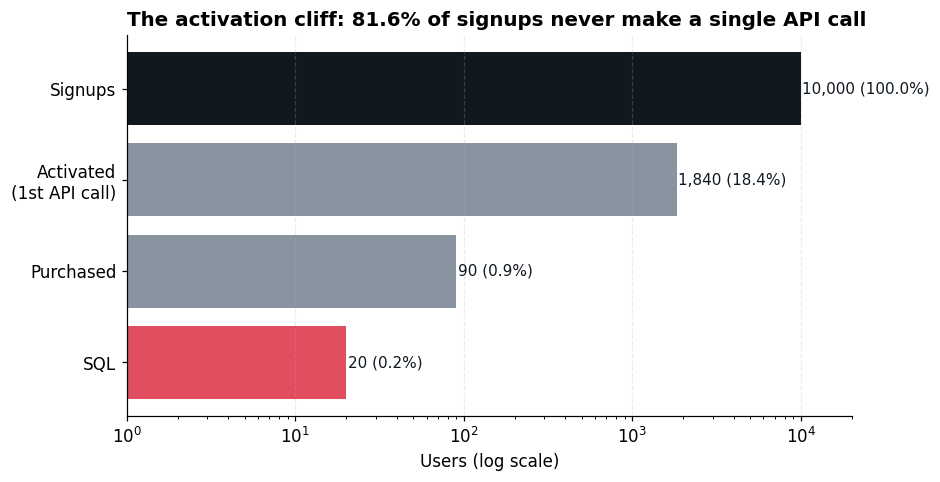

In [4]:
stages = ["Signups", "Activated\n(1st API call)", "Purchased", "SQL"]
values = [n, activated, purchased, became_sql]
pcts = [v / n * 100 for v in values]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.barh(stages[::-1], values[::-1], color=[DG_RED, DG_GREY, DG_GREY, DG_INK])
for bar, val, pct in zip(bars, values[::-1], pcts[::-1]):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f"{val:,} ({pct:.1f}%)", va="center", fontsize=10, color=DG_INK)
ax.set_xscale("log")
ax.set_xlim(1, n * 2)
ax.set_xlabel("Users (log scale)")
ax.set_title("The activation cliff: 81.6% of signups never make a single API call",
             loc="left")
ax.grid(axis="y", alpha=0)
fig.savefig(CHARTS / "01_funnel.png")
plt.show()

**Read:** Of 10,000 signups, only 1,840 (18.4%) make a first API call, 90 (0.9%) become paying customers, and 20 (0.2%) get tagged SQL. The credit-burn rate of 2.6% on $2M offered is essentially noise. The "freeloader" framing dies here.

## 3. Credit spend is severely power-law

Where does the $52K of consumed credit actually go?

In [5]:
total = df["total_credit_spend_usd"].sum()
sorted_spend = df["total_credit_spend_usd"].sort_values(ascending=False)

rows = []
for pct in (0.01, 0.05, 0.10, 0.25):
    k = int(n * pct)
    spend = sorted_spend.head(k).sum()
    rows.append({
        "Percentile": f"Top {pct*100:.1f}%",
        "Users": k,
        "Credit spend": f"${spend:,.0f}",
        "% of all spend": f"{spend/total*100:.1f}%",
    })
print(pd.DataFrame(rows).to_string(index=False))

top100 = df.nlargest(100, "total_credit_spend_usd")
print(f"\nTop 100 spenders profile:")
print(f"  Purchase rate:      {top100['purchased'].mean()*100:.0f}%")
print(f"  Business email:     {(top100['email_type']=='business').sum()}/100")
print(f"  Used SDK or API:    {(top100['integration_method'].isin(['sdk','direct_api'])).sum()}/100")
print(f"  Mean days_active:   {top100['days_active'].mean():.1f}")

Percentile  Users Credit spend % of all spend
  Top 1.0%    100      $24,305          46.6%
  Top 5.0%    500      $48,553          93.1%
 Top 10.0%   1000      $51,705          99.1%
 Top 25.0%   2500      $52,148         100.0%

Top 100 spenders profile:
  Purchase rate:      34%
  Business email:     28/100
  Used SDK or API:    100/100
  Mean days_active:   22.4


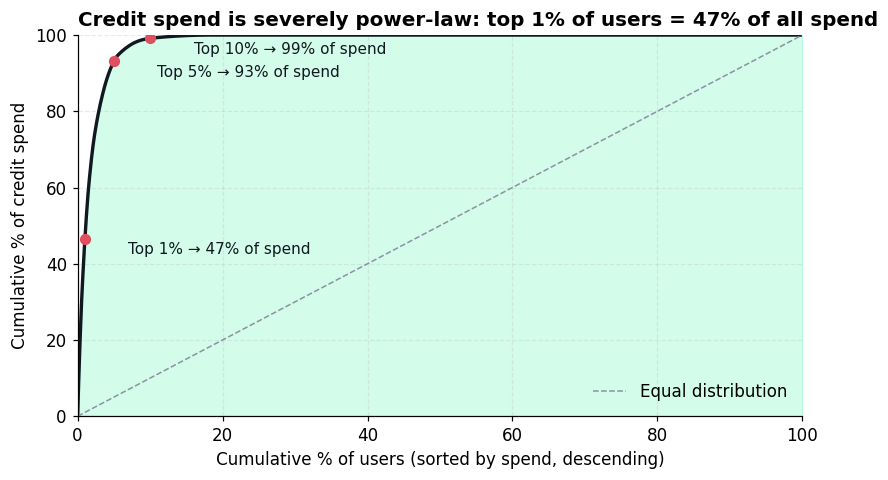

In [6]:
cum_share = sorted_spend.cumsum() / total * 100
user_share = (np.arange(1, n + 1) / n) * 100

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(user_share, cum_share, color=DG_INK, linewidth=2.2)
ax.fill_between(user_share, 0, cum_share, color=DG_GREEN, alpha=0.18)
ax.plot([0, 100], [0, 100], color=DG_GREY, linewidth=1, linestyle="--", label="Equal distribution")

for marker_pct in (1, 5, 10):
    share = cum_share.iloc[int(n * marker_pct / 100) - 1]
    ax.scatter([marker_pct], [share], color=DG_RED, zorder=5, s=40)
    ax.annotate(f"Top {marker_pct}% → {share:.0f}% of spend",
                xy=(marker_pct, share), xytext=(marker_pct + 6, share - 4),
                fontsize=10, color=DG_INK)

ax.set_xlabel("Cumulative % of users (sorted by spend, descending)")
ax.set_ylabel("Cumulative % of credit spend")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_title("Credit spend is severely power-law: top 1% of users = 47% of all spend",
             loc="left")
ax.legend(loc="lower right", frameon=False)
fig.savefig(CHARTS / "02_spend_concentration.png")
plt.show()

**Read:** The top 1% of users (100 people) consume 47% of all credits. Those 100 people convert at **34%** (vs 0.9% baseline) and **100% of them adopted an SDK or direct API integration**. The credit program is doing exactly what it's supposed to for the segment that matters. Don't kill it.

## 4. What predicts conversion

Three candidates: integration method, primary product, email type.

In [7]:
def grouped(col, dropna=True):
    g = df.groupby(col, dropna=dropna)["purchased"].agg(["sum", "mean", "count"])
    g["rate %"] = (g["mean"] * 100).round(2)
    return g[["count", "sum", "rate %"]].rename(columns={"sum": "purchases"})

print("=== Integration method ===")
g = grouped("integration_method")
g["lift_vs_none"] = (g["rate %"] / g.loc["none", "rate %"]).round(1)
print(g.to_string())

print("\n=== Primary product ===")
print(grouped("primary_product", dropna=False).to_string())

print("\n=== Email type ===")
print(grouped("email_type").to_string())

=== Integration method ===
                    count  purchases  rate %  lift_vs_none
integration_method                                        
console_only          668          3    0.45          11.2
direct_api            654         30    4.59         114.8
none                 8160          3    0.04           1.0
sdk                   518         54   10.42         260.5

=== Primary product ===
                    count  purchases  rate %
primary_product                             
audio_intelligence     97          4    4.12
stt                  1023         44    4.30
tts                   513         27    5.26
voice_agent           207         12    5.80
NaN                  8160          3    0.04

=== Email type ===
            count  purchases  rate %
email_type                          
business     2235         38    1.70
personal     7765         52    0.67


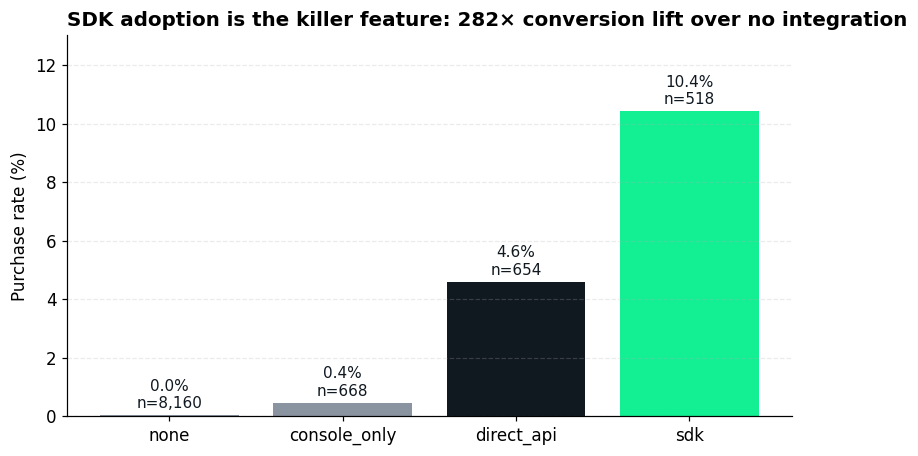

In [8]:
g = df.groupby("integration_method")["purchased"].agg(["sum", "mean", "count"])
order = ["none", "console_only", "direct_api", "sdk"]
g = g.reindex(order)
rates = g["mean"].values * 100
counts = g["count"].values

fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [DG_GREY, DG_GREY, DG_INK, DG_GREEN]
bars = ax.bar(order, rates, color=colors)
for bar, rate, count in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
            f"{rate:.1f}%\nn={count:,}", ha="center", fontsize=10, color=DG_INK)
ax.set_ylabel("Purchase rate (%)")
ax.set_ylim(0, max(rates) * 1.25)
ax.set_title("SDK adoption is the killer feature: 282× conversion lift over no integration",
             loc="left")
ax.grid(axis="x", alpha=0)
fig.savefig(CHARTS / "03_integration_lift.png")
plt.show()

**Read:**
- **SDK is the killer feature.** 10.4% conversion vs 0.04% for no integration. A 282× lift. Anything that gets a user to install an SDK in their first session is the highest-ROI investment Deepgram can make in onboarding.
- **Voice agent is the product to bet on.** Highest conversion rate (5.8%), smallest cohort (207 users). New product, hot category. Worth pulling forward.
- **Email type is the least interesting axis.** Business email converts 2.5× higher than personal — but personal email still produces 58% of all purchases (52/90) by volume. Don't disqualify gmail signups.

## 5. Monthly cohorts — the fire alarm

Most submissions will report aggregate numbers and stop. Splitting by signup cohort reveals the real headline.

In [9]:
df["signup_month"] = df["signup_date"].dt.to_period("M")
mc = df.groupby("signup_month").agg(
    n=("user_id", "count"),
    activated=("first_api_call_date", lambda s: s.notna().sum()),
    purchased=("purchased", "sum"),
)
mc["activation_rate %"] = (mc["activated"] / mc["n"] * 100).round(2)
mc["conversion_rate %"] = (mc["purchased"] / mc["n"] * 100).round(2)
print(mc.to_string())

                 n  activated  purchased  activation_rate %  conversion_rate %
signup_month                                                                  
2025-09       1670        299         18              17.90               1.08
2025-10       1639        301         19              18.36               1.16
2025-11       1674        322         17              19.24               1.02
2025-12       1751        361         17              20.62               0.97
2026-01       1677        291         12              17.35               0.72
2026-02       1544        258          7              16.71               0.45
2026-03         45          8          0              17.78               0.00


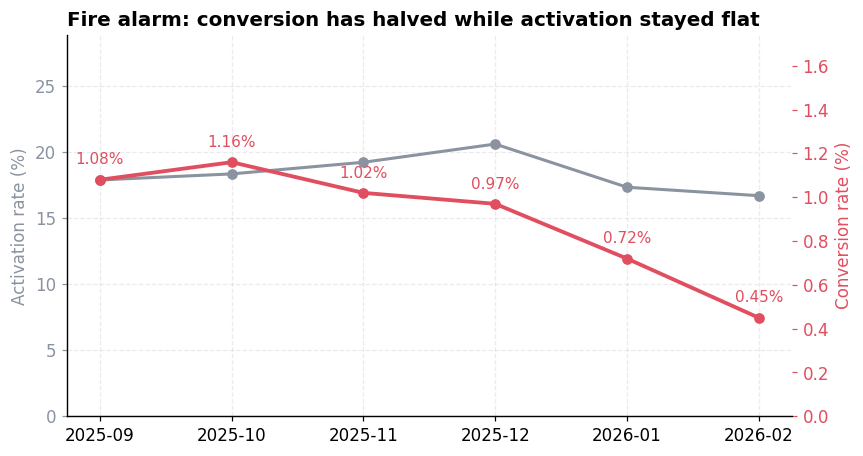

In [10]:
mc_plot = mc[mc["n"] > 100].copy()
months = [str(p) for p in mc_plot.index]

fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax2 = ax1.twinx()
ax1.plot(months, mc_plot["activation_rate %"], color=DG_GREY, marker="o", linewidth=2,
         label="Activation rate")
ax2.plot(months, mc_plot["conversion_rate %"], color=DG_RED, marker="o", linewidth=2.5,
         label="Conversion rate")

for x, y in zip(months, mc_plot["conversion_rate %"]):
    ax2.annotate(f"{y:.2f}%", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=10, color=DG_RED)

ax1.set_ylabel("Activation rate (%)", color=DG_GREY)
ax2.set_ylabel("Conversion rate (%)", color=DG_RED)
ax1.set_ylim(0, max(mc_plot["activation_rate %"]) * 1.4)
ax2.set_ylim(0, max(mc_plot["conversion_rate %"]) * 1.5)
ax1.tick_params(axis="y", colors=DG_GREY)
ax2.tick_params(axis="y", colors=DG_RED)
ax2.grid(False)
ax1.set_title("Fire alarm: conversion has halved while activation stayed flat",
              loc="left")
fig.savefig(CHARTS / "04_conversion_decay.png")
plt.show()

**Read:** Activation has been flat at ~17–20% across all six months. Conversion has **halved** from 1.16% (October cohort) to 0.45% (February cohort). Something downstream of activation is breaking.

**Caveat:** late cohorts have less time to convert (right-censoring). But the September 2025 cohort had six months and still only converted 1.08%, while the February 2026 cohort had two months and converted 0.45% — a 0.45% rate at 2 months is unlikely to mature past 1.0%, given the time-to-purchase distribution (median 4 days; p90 = 38 days; section 7).

**Three hypotheses to investigate:**
1. **Pricing change or paywall friction** introduced in Q1 2026.
2. **Onboarding regression** — a UX or quickstart change that broke the first-session "wow" moment.
3. **Competitive pressure** — a competitor (OpenAI Realtime, ElevenLabs, Cartesia) ate share among the activator pool.

The data alone can't distinguish these. Next step: pull product release notes + experiment log for Jan–Feb, talk to growth + pricing teams.

## 6. The SQL pipeline is disconnected from revenue

The current SQL definition is the wrong filter.

In [11]:
sql_and_purch = int((df["became_sql"] & df["purchased"]).sum())
sql_not_purch = int((df["became_sql"] & ~df["purchased"]).sum())
purch_not_sql = int((~df["became_sql"] & df["purchased"]).sum())

print(f"Total SQLs:                    {df['became_sql'].sum():>3}")
print(f"Total purchases:               {df['purchased'].sum():>3}")
print(f"SQL AND purchased:             {sql_and_purch:>3}")
print(f"SQL but never purchased:       {sql_not_purch:>3}  ({sql_not_purch/df['became_sql'].sum()*100:.0f}% of SQLs)")
print(f"Purchased but never SQL'd:     {purch_not_sql:>3}  ({purch_not_sql/df['purchased'].sum()*100:.0f}% of buyers)")

Total SQLs:                     20
Total purchases:                90
SQL AND purchased:               1
SQL but never purchased:        19  (95% of SQLs)
Purchased but never SQL'd:      89  (99% of buyers)


**Read:** Of 90 buyers, 89 were never flagged SQL. Of 20 SQLs, 19 never bought. The current SQL criteria are catching the wrong people. Sales is investing time in tire-kickers and missing 99% of actual revenue. **Rebuild the SQL definition.** Best candidate predictors from this data: SDK or direct_api integration adopted in first session, ≥$10 credit spend, ≥4 days active.

## 7. The leverage zone — activated but not purchased

Where to put the next dollar of growth investment.

In [12]:
activated = df[df["first_api_call_date"].notna()].copy()
not_purch = activated[~activated["purchased"]]
print(f"Activated:                       {len(activated):,}")
print(f"Of which not purchased:          {len(not_purch):,}")
print(f"Their total credit spend:        ${not_purch['total_credit_spend_usd'].sum():,.0f}")
print(f"Mean days_active:                {not_purch['days_active'].mean():.1f}")
print(f"One-and-done (1 active day):     {(not_purch['days_active']==1).sum():,} ({(not_purch['days_active']==1).mean()*100:.1f}%)")

Activated:                       1,840
Of which not purchased:          1,753
Their total credit spend:        $39,860
Mean days_active:                4.5
One-and-done (1 active day):     934 (53.3%)


             n  purchased  purchase_rate
bucket                                  
1 day      937          3       0.320171
2-3 days   274          4       1.459854
4-7 days   252          6       2.380952
8-30 days  329         61      18.541033
30+ days    48         13      27.083333


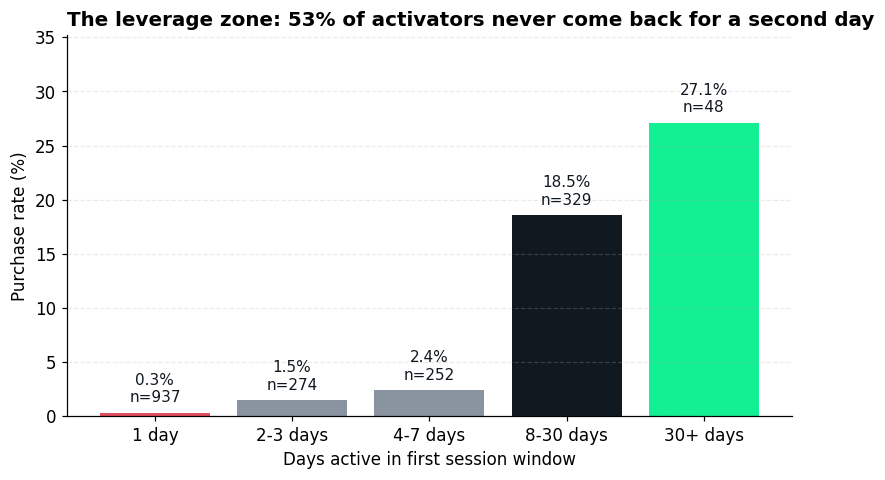

In [13]:
activated["bucket"] = pd.cut(
    activated["days_active"],
    bins=[0, 1, 3, 7, 30, 200],
    labels=["1 day", "2-3 days", "4-7 days", "8-30 days", "30+ days"],
)
g = activated.groupby("bucket", observed=True).agg(
    n=("user_id", "count"),
    purchased=("purchased", "sum"),
)
g["purchase_rate"] = g["purchased"] / g["n"] * 100
print(g.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(g.index.astype(str), g["purchase_rate"],
              color=[DG_RED, DG_GREY, DG_GREY, DG_INK, DG_GREEN])
for bar, rate, n_ in zip(bars, g["purchase_rate"], g["n"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{rate:.1f}%\nn={n_:,}", ha="center", fontsize=10, color=DG_INK)
ax.set_ylabel("Purchase rate (%)")
ax.set_xlabel("Days active in first session window")
ax.set_ylim(0, max(g["purchase_rate"]) * 1.3)
ax.set_title("The leverage zone: 53% of activators never come back for a second day",
             loc="left")
ax.grid(axis="x", alpha=0)
fig.savefig(CHARTS / "05_leverage_zone.png")
plt.show()

**Read:** Conversion scales monotonically and dramatically with days active:
- 1 active day → **0.3%** conversion (n=937)
- 8–30 days → **18.5%** (n=329)
- 30+ days → **27.1%** (n=48)

**The single most actionable insight in this dataset:** the 934 users who hit the API exactly once and never came back are the highest-leverage cohort. They proved intent. A second-day re-engagement motion (transactional email tied to first API success, "here's what to build next" walkthrough, dev-rel touch) is the obvious experiment.

## 8. Time to purchase + ROI sensitivity

The dataset is missing ARPU. Without it, the ROI question is unanswerable in absolute terms — but I can bracket the answer parametrically.

In [14]:
purch = df[df["purchased"] & df["purchase_date"].notna()].copy()
purch_post = purch[purch["purchase_date"] >= purch["signup_date"]]
ttp = (purch_post["purchase_date"] - purch_post["signup_date"]).dt.days
print(f"Valid post-signup purchases: {len(purch_post)}")
print(f"  median {ttp.median():.0f}d | mean {ttp.mean():.1f}d | p90 {ttp.quantile(.9):.0f}d")
print(f"  same-day:  {(ttp == 0).sum()} ({(ttp == 0).mean()*100:.0f}%)")

Valid post-signup purchases: 79
  median 4d | mean 13.0d | p90 38d
  same-day:  29 (37%)


In [15]:
burned = df["total_credit_spend_usd"].sum()
purchased = int(df["purchased"].sum())

rows = []
for arpu in (500, 2_500, 5_000, 25_000, 50_000):
    rev = purchased * arpu
    rows.append({
        "Assumed ARR/customer": f"${arpu:,}",
        "Total revenue": f"${rev:,}",
        "ROI on $52K credits": f"{rev/burned:.1f}×",
    })
print(pd.DataFrame(rows).to_string(index=False))

Assumed ARR/customer Total revenue ROI on $52K credits
                $500       $45,000                0.9×
              $2,500      $225,000                4.3×
              $5,000      $450,000                8.6×
             $25,000    $2,250,000               43.1×
             $50,000    $4,500,000               86.3×


**Read:**
- **Time to purchase:** median 4 days, with 37% of valid purchases happening **same-day**. There's a fast "install SDK → make it work → put a credit card down" motion. Design the funnel for it.
- **ROI is parametric on ARPU.** At $500/customer the program barely breaks even (0.9×). At $2,500 it's 4.3×. At Deepgram's likely enterprise ACV ($25K+), it's 40×+. **Ask the VP for actual ARPU.** That single number would change the recommendation from "hold" to "expand the credit budget."

---

## Recommendations

**Keep the $200 credit program.** The credit-leakage risk doesn't exist (2.6% burn rate). The program *works* for the segment that matters (top 1% of users convert at 34%, drive 47% of usage, all use SDK). Killing it would lose that.

**But redirect operational investment to four things, in priority order:**

1. **Fix the conversion-rate decay.** Conversion has halved in five months. Find out why before doing anything else. Pull pricing/release notes for Q1 2026, run an exit-survey on activated-but-not-converted Jan/Feb signups, check if a competitor launched.
2. **Make SDK adoption easier in the first session.** SDK = 282× conversion lift. Today only 5.2% of signups (518/10K) ever install one. If we doubled that to 10% with no other change, baseline conversion would roughly double.
3. **Re-engage the 934 one-and-done activators.** They proved intent and disappeared. A second-day re-engagement motion — transactional email tied to first API success, dev-rel outreach for higher-value users — is the highest-leverage experiment.
4. **Rebuild the SQL definition.** The current criteria miss 99% of actual buyers. Best candidate predictors from this data: SDK or direct_api adopted, ≥$10 credit spent, ≥4 days active in first 30 days.

**One bet:** double down on `voice_agent`. Highest conversion rate, smallest cohort, hottest category in market. Pull it forward in the activation flow.

---

## Open questions for the VP

1. **What's our actual ARPU/ARR per converted self-serve customer?** Without it I can only give parametric ROI. With it I can give one number.
2. **What changed in the product, pricing, or competitive landscape between October 2025 and February 2026?** The conversion-decay is the most urgent finding and the data alone can't explain it.
3. **What's the SQL definition?** Whatever it is, it's wrong. I'd like to propose a replacement.
4. **Are the pre-signup `purchase_date` / `sql_date` rows the result of returning customers, sales-touched leads, or duplicate accounts?** Affects how we report "self-serve PLG" funnel math.
5. **Do we have product-level instrumentation (which SDK methods get called, error rates, time-to-first-success)?** Almost everything that follows from this analysis depends on it.

---

## What I didn't have time for

- Statistical significance tests on the conversion-decay finding (would need more cohorts or a bootstrap).
- LTV / payback-period modeling — the data doesn't support it (no revenue per customer).
- A/B test design for the recommended interventions — I'd write that up separately if asked.
- Cross-tabs between integration method × product (e.g. is `voice_agent + SDK` a leading conversion segment?).

---

## How I worked

I used **Claude Code (Opus 4.7)** as a pair-programmer for this analysis:
- Initial dataset profiling and shape-of-the-data exploration.
- Drafting the chart code (matplotlib styling, layouts).
- Sanity-checking my numbers against the raw CSV.

I used Claude with a "reflect first, then build" pattern: I had it interrogate the prompt and the data before writing any output. The reframe in the headline ("the question is wrong; here's the right one") is mine, prompted by the Claude exploration. All analysis decisions, the recommendations, and the prioritization are mine. The notebook is human-reviewed.

If hired, I'd build a similar workflow in-house: deterministic ETL + analyst-led question framing + AI-assisted chart and code drafting. That keeps the senior analyst's time on judgment, not on `df.groupby` boilerplate.